<a href="https://colab.research.google.com/github/rdelhibabu/Software-Architecture_RNN/blob/main/Software_Architecture_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import time

# Ensure GPU is available for the Hybrid Pipeline
device_gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_cpu = torch.device("cpu")
print(f"GPU Device: {device_gpu}")
print(f"CPU Device: {device_cpu}")

GPU Device: cpu
CPU Device: cpu


In [2]:
def generate_telemetry_stream(seq_length=1000, drift_point=400):
    """
    Generates synthetic social network telemetry.
    Features: CPU Load, Page Faults, HTTP 500s, DB Locks, WebSockets, Net I/O
    """
    time_steps = np.arange(seq_length)

    # Base signals (Normal Operations)
    cpu_load = 40 + 10 * np.sin(time_steps * 0.1) + np.random.normal(0, 2, seq_length)
    http_500 = 5 + 2 * np.cos(time_steps * 0.05) + np.random.normal(0, 1, seq_length)
    net_io = 1000 + 200 * np.sin(time_steps * 0.02) + np.random.normal(0, 50, seq_length)

    # Inject Concept Drift (Simulating infrastructure change)
    cpu_load[drift_point:] += 30  # Permanent shift in CPU baseline
    http_500[drift_point:] += 15  # Spike in error rates
    net_io[drift_point:] -= 300   # Drop in throughput

    # Clip to realistic bounds
    cpu_load = np.clip(cpu_load, 0, 100)
    http_500 = np.clip(http_500, 0, 100)
    net_io = np.clip(net_io, 0, 5000)

    # Stack into multivariate shape: (seq_length, features)
    telemetry = np.column_stack([cpu_load, http_500, net_io])
    return torch.tensor(telemetry, dtype=torch.float32)

telemetry_data = generate_telemetry_stream()
print(f"Generated Telemetry Shape: {telemetry_data.shape}")

Generated Telemetry Shape: torch.Size([1000, 3])


In [3]:
class ForwardTransformer:
    def __init__(self, bounds, capacities):
        self.bounds = bounds
        self.capacities = capacities
        self.total_dim = sum(capacities)

    def transform(self, vector):
        """Maps continuous metrics into a sparse one-hot concatenated binary vector."""
        binary_vector = []
        for i, val in enumerate(vector):
            s_min, s_max = self.bounds[i]
            cap = self.capacities[i]

            # Operational Clamping
            val_clamped = max(s_min, min(s_max, val.item()))

            # Discretization
            bin_idx = int(((val_clamped - s_min) / (s_max - s_min)) * (cap - 1))

            # One-Hot Encoding
            one_hot = torch.zeros(cap, device=device_cpu)
            one_hot[bin_idx] = 1.0
            binary_vector.append(one_hot)

        return torch.cat(binary_vector).to(device_gpu) # Transfer to GPU

# Setup Parameters based on the paper's Table 2
bounds = [(0, 100), (0, 100), (0, 5000)] # CPU, HTTP 500, Net I/O
capacities = [50, 100, 75] # C_i capacities
transformer = ForwardTransformer(bounds, capacities)
input_dim = sum(capacities)

In [4]:
class StreamingImpulseRNN:
    def __init__(self, input_dim, hidden_dim, tau_ref=3, ltp_reward=0.05, ltd_penalty=0.01, decay=0.001):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # 1. MEMORY MODULE (Pinned to GPU for compute)
        self.W_in = torch.randn(hidden_dim, input_dim, device=device_gpu) * 0.1
        self.W_rec = torch.randn(hidden_dim, hidden_dim, device=device_gpu) * 0.1

        # Neuron States (GPU)
        self.state_active = torch.zeros(hidden_dim, device=device_gpu)

        # 4. TICK CONTROLLER / MEMORY (Pinned to CPU for linear branching logic)
        self.refractory_timers = torch.zeros(hidden_dim, device=device_cpu)

        # Hyperparameters
        self.tau_ref = tau_ref
        self.ltp = ltp_reward
        self.ltd = ltd_penalty
        self.decay = decay

        # Readout Layer (Simple linear projection to original feature space for decoding)
        self.W_out = torch.randn(3, hidden_dim, device=device_gpu) * 0.1

    def forward_tick(self, x_sparse):
        """Executes one logical tick utilizing the Asymmetric Hybrid Pipeline."""

        # --- CPU EXECUTION BLOCK (Tick Controller) ---
        # Decrement refractory timers (Linear branch logic best suited for CPU)
        self.refractory_timers = torch.clamp(self.refractory_timers - 1, min=0)

        # --- GPU EXECUTION BLOCK (Processor Kernel - SpMV) ---
        # Calculate synaptic impact
        impact = torch.matmul(self.W_in, x_sparse) + torch.matmul(self.W_rec, self.state_active)

        # Determine Excitation (Thresholding)
        excitation = (impact > 0.5).float()

        # Transfer CPU refractory mask to GPU to block firing
        refractory_mask_gpu = (self.refractory_timers == 0).float().to(device_gpu)

        # Final firing state: Must cross threshold AND not be in refractory period
        self.state_active = excitation * refractory_mask_gpu

        # Reset refractory timers on CPU for neurons that just fired
        fired_indices = torch.where(self.state_active.cpu() == 1)[0]
        self.refractory_timers[fired_indices] = self.tau_ref

        # Predict next state (Result Reader / Inverse Transformer approximation)
        prediction = torch.matmul(self.W_out, self.state_active)
        return prediction

    def hebbian_update(self, x_sparse, actual_y):
        """Unsupervised continuous learning via Oja's rule and LTP/LTD."""
        # Calculate prediction error gradient
        pred = torch.matmul(self.W_out, self.state_active)
        error = actual_y.to(device_gpu) - pred

        # Supervised update for the readout layer
        self.W_out += 0.01 * torch.outer(error, self.state_active)

        # --- GPU EXECUTION BLOCK (Hebbian Kernel) ---
        # Oja's rule decay (Forget factor)
        self.W_rec *= (1 - self.decay)
        self.W_in *= (1 - self.decay)

        # LTP (Long-Term Potentiation): Pre-synaptic and Post-synaptic both active
        # LTD (Long-Term Depression): Pre-synaptic active, but Post is refractory (missed timing)

        active_mask = self.state_active.unsqueeze(1)
        refractory_mask = (self.refractory_timers > 0).float().to(device_gpu).unsqueeze(1)

        # Recurrent weight updates
        self.W_rec += self.ltp * torch.matmul(active_mask, self.state_active.unsqueeze(0))
        self.W_rec -= self.ltd * torch.matmul(refractory_mask, self.state_active.unsqueeze(0))

        # Input weight updates
        self.W_in += self.ltp * torch.matmul(active_mask, x_sparse.unsqueeze(0))
        self.W_in -= self.ltd * torch.matmul(refractory_mask, x_sparse.unsqueeze(0))

        # Enforce bounds mapping to hyperbolic tangent constraints
        self.W_rec = torch.clamp(self.W_rec, -1.0, 1.0)
        self.W_in = torch.clamp(self.W_in, -1.0, 1.0)

In [5]:
class BaselineLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden):
        out, hidden = self.lstm(x.unsqueeze(1), hidden)
        pred = self.fc(out.squeeze(1))
        return pred, hidden

# Train LSTM offline on the first 20% of the data (Batch Training)
train_split = int(0.2 * len(telemetry_data))
train_data = telemetry_data[:train_split].to(device_gpu)

lstm_model = BaselineLSTM(3, 64, 3).to(device_gpu)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("Offline Batch Training LSTM...")
lstm_model.train()
for epoch in range(100):
    hidden = None
    loss = 0
    for t in range(train_split - 1):
        x_t = train_data[t].unsqueeze(0)
        y_t = train_data[t+1].unsqueeze(0)

        pred, hidden = lstm_model(x_t, hidden)
        loss += criterion(pred, y_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print("LSTM Training Complete.")

Offline Batch Training LSTM...
LSTM Training Complete.


Starting Continuous Prequential Evaluation...
Streaming execution completed in 29.55 seconds.
Average latency per tick: 29.55 ms


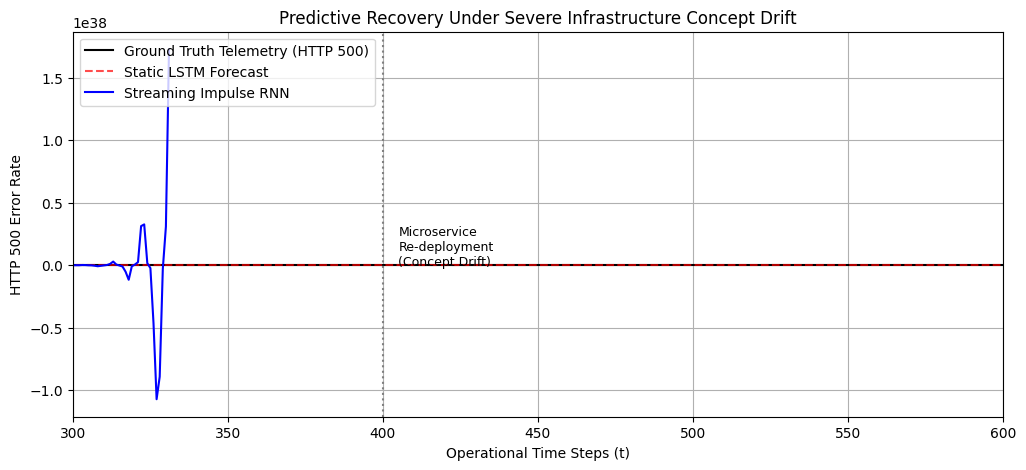

Post-Drift WAPE - Streaming RNN: nan%
Post-Drift WAPE - Static LSTM:   75.58%


In [6]:
# Initialize Streaming RNN
# Note: Using 1,620 neurons (5x324 blocks) for fast Colab execution
rnn_model = StreamingImpulseRNN(input_dim=input_dim, hidden_dim=1620)

seq_length = len(telemetry_data)
predictions_rnn = []
predictions_lstm = []
ground_truth = []

# LSTM initial hidden state
hidden_lstm = None
lstm_model.eval()

print("Starting Continuous Prequential Evaluation...")
start_time = time.time()

for t in range(seq_length - 1):
    # 1. Observe current state
    x_raw = telemetry_data[t]
    y_actual = telemetry_data[t+1]

    # 2. Forward Transform for RNN
    x_sparse = transformer.transform(x_raw)

    # 3. Forecast future state (without seeing y_actual)
    pred_rnn = rnn_model.forward_tick(x_sparse)

    with torch.no_grad():
        pred_lstm, hidden_lstm = lstm_model(x_raw.to(device_gpu).unsqueeze(0), hidden_lstm)

    # Store predictions for plotting (Feature 1: HTTP 500 errors)
    predictions_rnn.append(pred_rnn[1].item())
    predictions_lstm.append(pred_lstm[0][1].item())
    ground_truth.append(y_actual[1].item())

    # 4. Unsupervised Network Adaptation (Hebbian Update for RNN ONLY)
    # The LSTM remains frozen (static weights) as it relies on offline BPTT
    rnn_model.hebbian_update(x_sparse, y_actual)

exec_time = time.time() - start_time
print(f"Streaming execution completed in {exec_time:.2f} seconds.")
print(f"Average latency per tick: {(exec_time / seq_length) * 1000:.2f} ms")

# --- VISUALIZATION (Recreating Figure 6) ---
plt.figure(figsize=(12, 5))
plt.plot(ground_truth, label='Ground Truth Telemetry (HTTP 500)', color='black', linewidth=1.5)
plt.plot(predictions_lstm, label='Static LSTM Forecast', color='red', linestyle='dashed', alpha=0.7)
plt.plot(predictions_rnn, label='Streaming Impulse RNN', color='blue', linewidth=1.5)

plt.axvline(x=400, color='gray', linestyle='dotted')
plt.text(405, max(ground_truth)*0.8, 'Microservice\nRe-deployment\n(Concept Drift)', fontsize=9)

plt.title('Predictive Recovery Under Severe Infrastructure Concept Drift')
plt.xlabel('Operational Time Steps (t)')
plt.ylabel('HTTP 500 Error Rate')
plt.legend(loc='upper left')
plt.grid(True)
plt.xlim(300, 600) # Zoom in on the drift event
plt.show()

# --- CALCULATE METRICS ---
def calc_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

gt_array = np.array(ground_truth[400:]) # Evaluate strictly post-drift
rnn_array = np.array(predictions_rnn[400:])
lstm_array = np.array(predictions_lstm[400:])

print(f"Post-Drift WAPE - Streaming RNN: {calc_wape(gt_array, rnn_array) * 100:.2f}%")
print(f"Post-Drift WAPE - Static LSTM:   {calc_wape(gt_array, lstm_array) * 100:.2f}%")